# Collating Greek editions at the word level

### *Sophocles,* Antigone *(`tlg0011.tlg002`) — N editions, one word-aligned collation*

The editions disagree on **line numbering** (bracketed lines, atheteses, transpositions),
so we cannot align on `@n`. Instead we align on the **word stream** itself.

**What this notebook does**

1. Parses every `*.xml` TEI edition found under `INPUT_DIRS` into a token stream, handling
   `<add>`/`<del>`/`<gap>` and skipping milestone markup (`<milestone>`, `<pb>`, `<s>`, `<lb>`).
2. Builds two normalization keys per token: an **orthography-insensitive** key used for
   *alignment* (folds accents, breathings, iota subscript↔adscript, the five different
   elision/apostrophe characters in use, punctuation, final sigma), and an **accent-sensitive**
   form key used to detect *spelling* differences.
3. Aligns every pair of editions with `difflib.SequenceMatcher` and derives two distance
   matrices: **substantive** (different words / readings) and **orthographic** (same word,
   different spelling).
4. Answers *“which text is closer to which”* with UPGMA dendrograms, a neighbour-joining
   tree (Newick), and heatmaps — separately for the substantive and orthographic signals.
5. Produces a **reference-anchored collation table** and an **apparatus** (per-locus list of
   variant readings grouped by siglum), exported as TSV crosswalks — *source XML is never modified.*

**Adding the rest of the ~16 editions:** just drop the files into the input folder. Everything
is discovered by a recursive glob; the **siglum** is derived from each filename stem, so no
particular naming scheme is assumed. Check the siglum→file table printed after loading.

**Known limitation.** The wide collation table and apparatus are *reference-anchored* (one column
per reference token), so a reading the reference lacks but others share appears as an *insertion*
rather than its own column. The distance matrix and dendrograms do **not** have this bias — they
are computed from symmetric pairwise alignments. Change `REFERENCE` to re-anchor.

## 0 · Configuration

In [6]:
import glob, os, re, unicodedata, difflib, itertools, html as _html
from collections import defaultdict
import numpy as np
import pandas as pd
from lxml import etree

# --- edit these ----------------------------------------------------------
INPUT_DIRS = ["/Users/gcrane/github/AntigonesPublic/greek", "/Users/gcrane/github/AntigonePrivate/greek"]   # search both; drop new editions in either
OUTPUT_DIR = "/Users/gcrane/github/AntigonesPublic/greek/outputs"  # TSV / Newick crosswalks land here
REFERENCE  = "storr"                            # baseline for the wide collation table
FILE_GLOB  = "soph.ant.*.xml"                            # any .xml; siglum derived from the filename stem
# -------------------------------------------------------------------------
# NB: OUTPUT_DIR is created later (in the export cell), not here, so that a
#     wrong INPUT_DIR is reported honestly instead of being silently created.
TEI = "{http://www.tei-c.org/ns/1.0}"

## 1 · Parse TEI → token streams

For each `<l>` we walk its content in document order. Milestone-like elements carry no line
text and are skipped; `<gap/>` becomes a sentinel token `⟨gap⟩`; `<add>`/`<del>` text is kept
but flagged so an athetised or editorially-supplied word is never silently lost or merged.

In [7]:
def siglum_of(fp):
    """Filename stem -> siglum. Tweak the strip rules to match your naming."""
    stem = os.path.splitext(os.path.basename(fp))[0]
    stem = re.sub(r"^(soph[._]?ant[._]?)", "", stem, flags=re.I)   # drop a leading soph_ant_
    stem = re.sub(r"[._-]?grc\d?$", "", stem, flags=re.I)         # drop a trailing _grc / -grc1
    return stem or os.path.splitext(os.path.basename(fp))[0]

def discover():
    seen = {}
    for d in INPUT_DIRS:
        if not os.path.isdir(d):
            print(f"(skip, not a directory) {d}")
            continue
        for fp in sorted(glob.glob(os.path.join(d, "**", FILE_GLOB), recursive=True)):
            sig = siglum_of(fp)
            if sig in seen:
                print(f"(duplicate siglum {sig!r}; keeping first) {fp}")
                continue
            seen[sig] = fp
    if not seen:
        print("No files matched. Check INPUT_DIRS and FILE_GLOB.")
    return seen

SKIP = {"milestone", "pb", "lb", "s", "note", "speaker", "head", "stage"}

def line_text_and_flags(l):
    """Yield (text_chunk, flag) with flag in {'', 'del', 'add'}; <gap/> -> sentinel."""
    out = []
    def walk(node, flag):
        tag = etree.QName(node).localname
        if tag in SKIP:
            if node.tail: out.append((node.tail, flag))
            return
        if tag == "gap":
            out.append((" ⟨gap⟩ ", flag))
            if node.tail: out.append((node.tail, flag))
            return
        f = "del" if tag == "del" else ("add" if tag == "add" else flag)
        if node.text: out.append((node.text, f))
        for ch in node: walk(ch, f)
        if node.tail: out.append((node.tail, flag))
    if l.text: out.append((l.text, ''))
    for ch in l: walk(ch, '')
    return out

TOKEN_SPLIT = re.compile(r"\s+")

def load_edition(siglum, fp):
    t = etree.parse(fp)
    ed = t.find(f".//{TEI}div[@type='edition']")
    if ed is None:
        ed = t.find(f".//{TEI}body")
    rows, widx = [], 0
    for l in ed.iter(f"{TEI}l"):
        line_n = l.get("n")
        for chunk, flag in line_text_and_flags(l):
            for w in TOKEN_SPLIT.split(chunk.strip()):
                if not w:
                    continue
                rows.append(dict(siglum=siglum, widx=widx, line_n=line_n, raw=w, flag=flag))
                widx += 1
    return pd.DataFrame(rows)

## 2 · Normalization keys

`key_word` is the **alignment / identity** key: two tokens with the same `key_word` count as
*the same word*. It neutralizes the five elision characters actually present in these files
(U+02BC ʼ, U+1FBD ᾽, U+1FBF ᾿, U+0027 ', U+2019 ’), strips accents and breathings,
folds **iota subscript with adscript** (ἷην ↔ ἶιν), drops editorial punctuation and
daggers, lowercases, and merges final sigma. `key_form` keeps the diacritics so we can still
*see* spelling habits.

In [8]:
ELISION = "\u02bc\u1fbd\u1fbf'\u2019\u0060\u00b4\u2018\u0375\u2032"
_ELIS_DROP   = {ord(c): None   for c in ELISION}
_ELIS_STRICT = {ord(c): 0x2019 for c in ELISION}
PUNCT = ".,\u00b7\u0387;:?!\u2014\u2013\u2012\u2010\"\u00ab\u00bb\u2026\u2020[]\u27e8\u27e9()<>{}/\u2021*"
_PUNCT_DROP  = {ord(c): None for c in PUNCT}

def _fold_combining(s):
    """NFD, turn combining ypogegrammeni into a real iota, drop other combining marks."""
    s = unicodedata.normalize("NFD", s)
    buf = []
    for c in s:
        if c == "\u0345":            # COMBINING GREEK YPOGEGRAMMENI (subscript)
            buf.append("\u03b9")      # -> ι  (so ῷ folds with ωι)
        elif unicodedata.combining(c):
            continue
        else:
            buf.append(c)
    return "".join(buf)

def key_word(tok):
    if tok == "\u27e8gap\u27e9": return tok
    t = tok.translate(_ELIS_DROP).translate(_PUNCT_DROP)
    t = _fold_combining(t).lower()
    return t.replace("\u03c2", "\u03c3")

def key_form(tok):
    if tok == "\u27e8gap\u27e9": return tok
    t = unicodedata.normalize("NFC", tok).translate(_ELIS_STRICT).translate(_PUNCT_DROP).lower()
    return t.replace("\u03c2", "\u03c3")

# demo: the apostrophe zoo and iota subscript/adscript all collapse for alignment
demo = ["ἀπʼ", "ἀπ᾽", "ἀπ’", "ἀπ᾿", "νῷν", "νῶιν"]
pd.DataFrame({"raw": demo, "key_word": [key_word(x) for x in demo], "key_form": [key_form(x) for x in demo]})

,raw,key_word,key_form
0,ἀπʼ,απ,ἀπ’
1,ἀπ᾽,απ,ἀπ’
2,ἀπ’,απ,ἀπ’
3,ἀπ᾿,απ,ἀπ’
4,νῷν,νωιν,νῷν
5,νῶιν,νωιν,νῶιν


## 3 · Load every edition

In [9]:
found = discover()
EDS = {}
for s, fp in found.items():
    df = load_edition(s, fp)
    df["kw"] = df["raw"].map(key_word)
    df["kf"] = df["raw"].map(key_form)
    EDS[s] = df
SIGLA = sorted(EDS)
if REFERENCE not in EDS:
    hits = [s for s in SIGLA if REFERENCE.lower() in s.lower()]
    if len(hits) == 1:
        REFERENCE = hits[0]; print(f'REFERENCE resolved to {REFERENCE!r}')
    elif SIGLA:
        REFERENCE = max(SIGLA, key=lambda s: len(EDS[s]))
        print(f'REFERENCE not found; falling back to longest edition {REFERENCE!r}')
    else:
        raise RuntimeError('No editions loaded — discover() found nothing; check INPUT_DIRS.')
summary = pd.DataFrame([{"siglum": s, "tokens": len(EDS[s]),
                         "file": os.path.basename(found[s])} for s in SIGLA])
print(summary.to_string(index=False))
EDS[REFERENCE].head(6)

   siglum  tokens                       file
  benloew    7489   soph.ant.benloew.grc.xml
   boeckh    7387    soph.ant.boeckh.grc.xml
    bothe    7432     soph.ant.bothe.grc.xml
    brown    7396     soph.ant.brown.grc.xml
  colonna    7409   soph.ant.colonna.grc.xml
     dain    7416      soph.ant.dain.grc.xml
     dawe    7454      soph.ant.dawe.grc.xml
 griffith    7409  soph.ant.griffith.grc.xml
  hermann    7404   soph.ant.hermann.grc.xml
     jebb    7381      soph.ant.jebb.grc.xml
       lj    7413        soph.ant.lj.grc.xml
  pearson    7402   soph.ant.pearson.grc.xml
reinhardt    7400 soph.ant.reinhardt.grc.xml
    storr    7359     soph.ant.storr.grc.xml


,siglum,widx,line_n,raw,flag,kw,kf
0,storr,0,1,ὦ,,ω,ὦ
1,storr,1,1,κοινὸν,,κοινον,κοινὸν
2,storr,2,1,αὐτάδελφον,,αυταδελφον,αὐτάδελφον
3,storr,3,1,Ἰσμήνης,,ισμηνησ,ἰσμήνησ
4,storr,4,1,"κάρα,",,καρα,κάρα
5,storr,5,2,ἆρʼ,,αρ,ἆρ’


## 4 · Pairwise alignment → two distance matrices

For each pair we align the `key_word` streams (`autojunk=False` so frequent function words
are not discarded). Within an `equal` run the words match; we additionally check `key_form`
to count **orthographic** differences. `replace`/`insert`/`delete` are **substantive** differences.

- **`d_word`** = (substituted + inserted + deleted words) / aligned length — the *reading* signal.
- **`d_ortho`** = (same word, different spelling) / matched words — the *spelling-habit* signal.

In [10]:
def align(a_keys, b_keys):
    return difflib.SequenceMatcher(None, a_keys, b_keys, autojunk=False).get_opcodes()

def pair_stats(sa, sb):
    A, B = EDS[sa], EDS[sb]
    ak, bk = A["kw"].tolist(), B["kw"].tolist()
    af, bf = A["kf"].tolist(), B["kf"].tolist()
    same = subst = indel = ortho = 0
    for tag, i1, i2, j1, j2 in align(ak, bk):
        if tag == "equal":
            for k in range(i2 - i1):
                same += 1
                if af[i1 + k] != bf[j1 + k]: ortho += 1
        elif tag == "replace":
            subst += max(i2 - i1, j2 - j1)
        else:
            indel += (i2 - i1) + (j2 - j1)
    total = same + subst + indel
    return dict(same=same, subst=subst, indel=indel, ortho=ortho, total=total,
                d_word=(subst + indel) / total, d_ortho=ortho / max(same, 1))

N = len(SIGLA)
Dword  = pd.DataFrame(np.zeros((N, N)), index=SIGLA, columns=SIGLA)
Dortho = pd.DataFrame(np.zeros((N, N)), index=SIGLA, columns=SIGLA)
for sa, sb in itertools.combinations(SIGLA, 2):
    st = pair_stats(sa, sb)
    Dword.loc[sa, sb] = Dword.loc[sb, sa] = st["d_word"]
    Dortho.loc[sa, sb] = Dortho.loc[sb, sa] = st["d_ortho"]

print("Substantive distance ×1000 (lower = closer readings):")
display((Dword * 1000).round(1))
print("Orthographic distance ×1000 (lower = same spelling habits):")
(Dortho * 1000).round(1)

Substantive distance ×1000 (lower = closer readings):


,benloew,boeckh,bothe,brown,colonna,dain,dawe,griffith,hermann,jebb,lj,pearson,reinhardt,storr
benloew,0.0,58.3,97.9,79.0,69.0,74.6,87.2,70.4,58.2,67.5,86.7,71.4,77.2,69.2
boeckh,58.3,0.0,91.3,61.7,43.2,47.1,72.9,56.8,29.8,39.8,56.9,55.9,49.5,41.5
bothe,97.9,91.3,0.0,118.6,104.3,106.6,129.3,115.5,92.3,98.9,112.2,113.8,108.9,100.5
brown,79.0,61.7,118.6,0.0,48.9,51.5,33.9,31.7,63.9,45.9,48.4,38.5,42.6,48.9
colonna,69.0,43.2,104.3,48.9,0.0,19.9,57.6,38.9,44.2,32.4,42.5,41.4,29.9,34.7
dain,74.6,47.1,106.6,51.5,19.9,0.0,56.8,42.0,47.4,36.8,46.7,46.4,28.9,36.1
dawe,87.2,72.9,129.3,33.9,57.6,56.8,0.0,39.3,74.2,55.7,56.7,47.3,50.7,57.8
griffith,70.4,56.8,115.5,31.7,38.9,42.0,39.3,0.0,59.9,38.7,31.9,26.9,38.8,40.1
hermann,58.2,29.8,92.3,63.9,44.2,47.4,74.2,59.9,0.0,43.9,60.2,60.3,52.0,43.7
jebb,67.5,39.8,98.9,45.9,32.4,36.8,55.7,38.7,43.9,0.0,41.8,42.7,31.6,12.0


Orthographic distance ×1000 (lower = same spelling habits):


,benloew,boeckh,bothe,brown,colonna,dain,dawe,griffith,hermann,jebb,lj,pearson,reinhardt,storr
benloew,0.0,25.8,18.5,68.5,25.1,25.0,64.6,66.3,32.7,26.9,29.4,27.9,63.3,25.7
boeckh,25.8,0.0,29.0,55.5,12.9,13.1,51.7,52.7,15.0,13.9,15.1,16.3,50.9,13.1
bothe,18.5,29.0,0.0,70.8,27.7,28.5,66.9,68.4,35.1,28.8,32.1,30.4,66.4,28.5
brown,68.5,55.5,70.8,0.0,53.7,52.5,7.5,12.5,63.5,51.2,52.2,54.0,11.3,52.4
colonna,25.1,12.9,27.7,53.7,0.0,2.2,48.9,49.0,21.0,6.9,7.0,8.0,47.5,5.0
dain,25.0,13.1,28.5,52.5,2.2,0.0,48.0,48.3,21.8,7.0,6.9,7.7,47.3,5.2
dawe,64.6,51.7,66.9,7.5,48.9,48.0,0.0,7.8,59.6,46.2,49.7,49.3,6.9,47.0
griffith,66.3,52.7,68.4,12.5,49.0,48.3,7.8,0.0,61.1,47.0,47.2,51.4,8.2,47.7
hermann,32.7,15.0,35.1,63.5,21.0,21.8,59.6,61.1,0.0,22.5,25.0,25.1,59.5,22.2
jebb,26.9,13.9,28.8,51.2,6.9,7.0,46.2,47.0,22.5,0.0,7.4,6.0,46.1,7.5


### Heatmaps

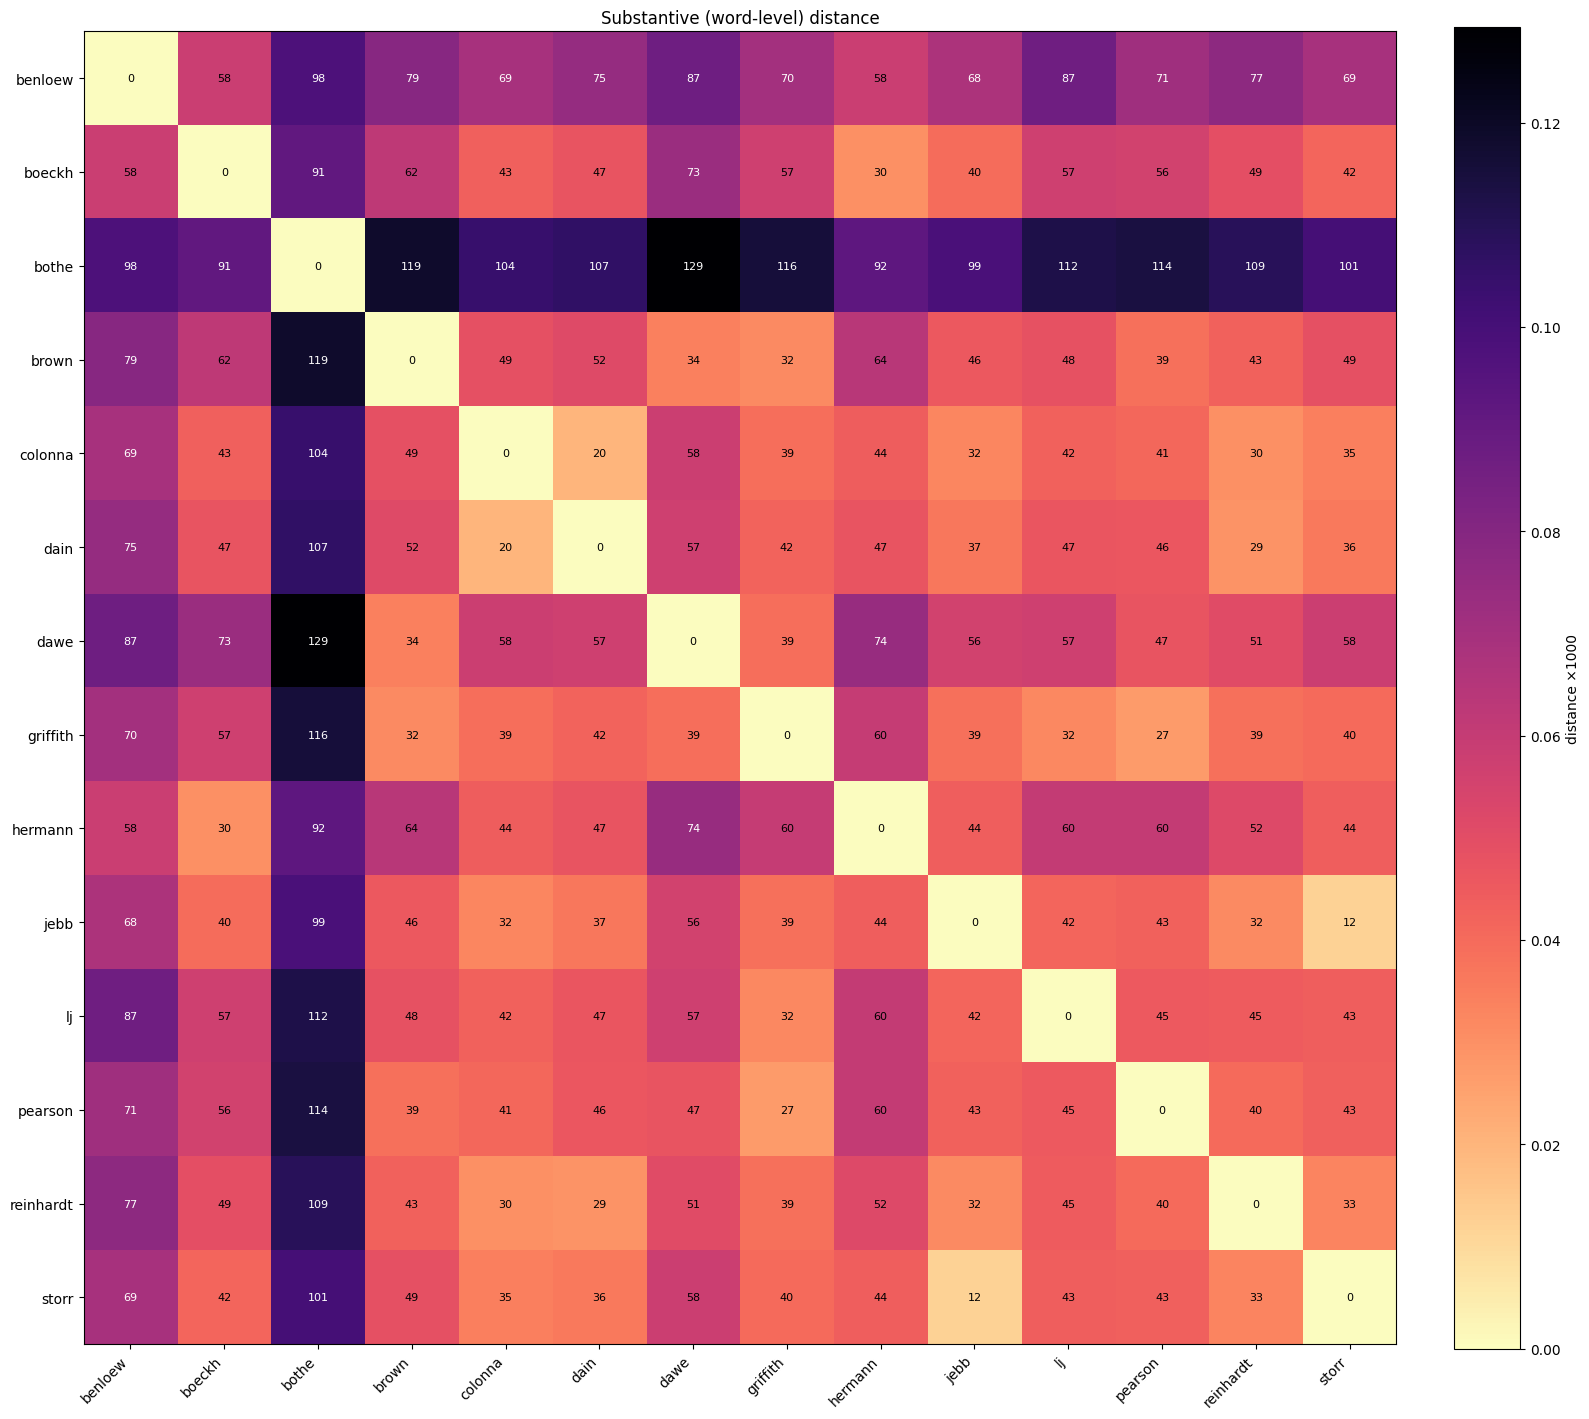

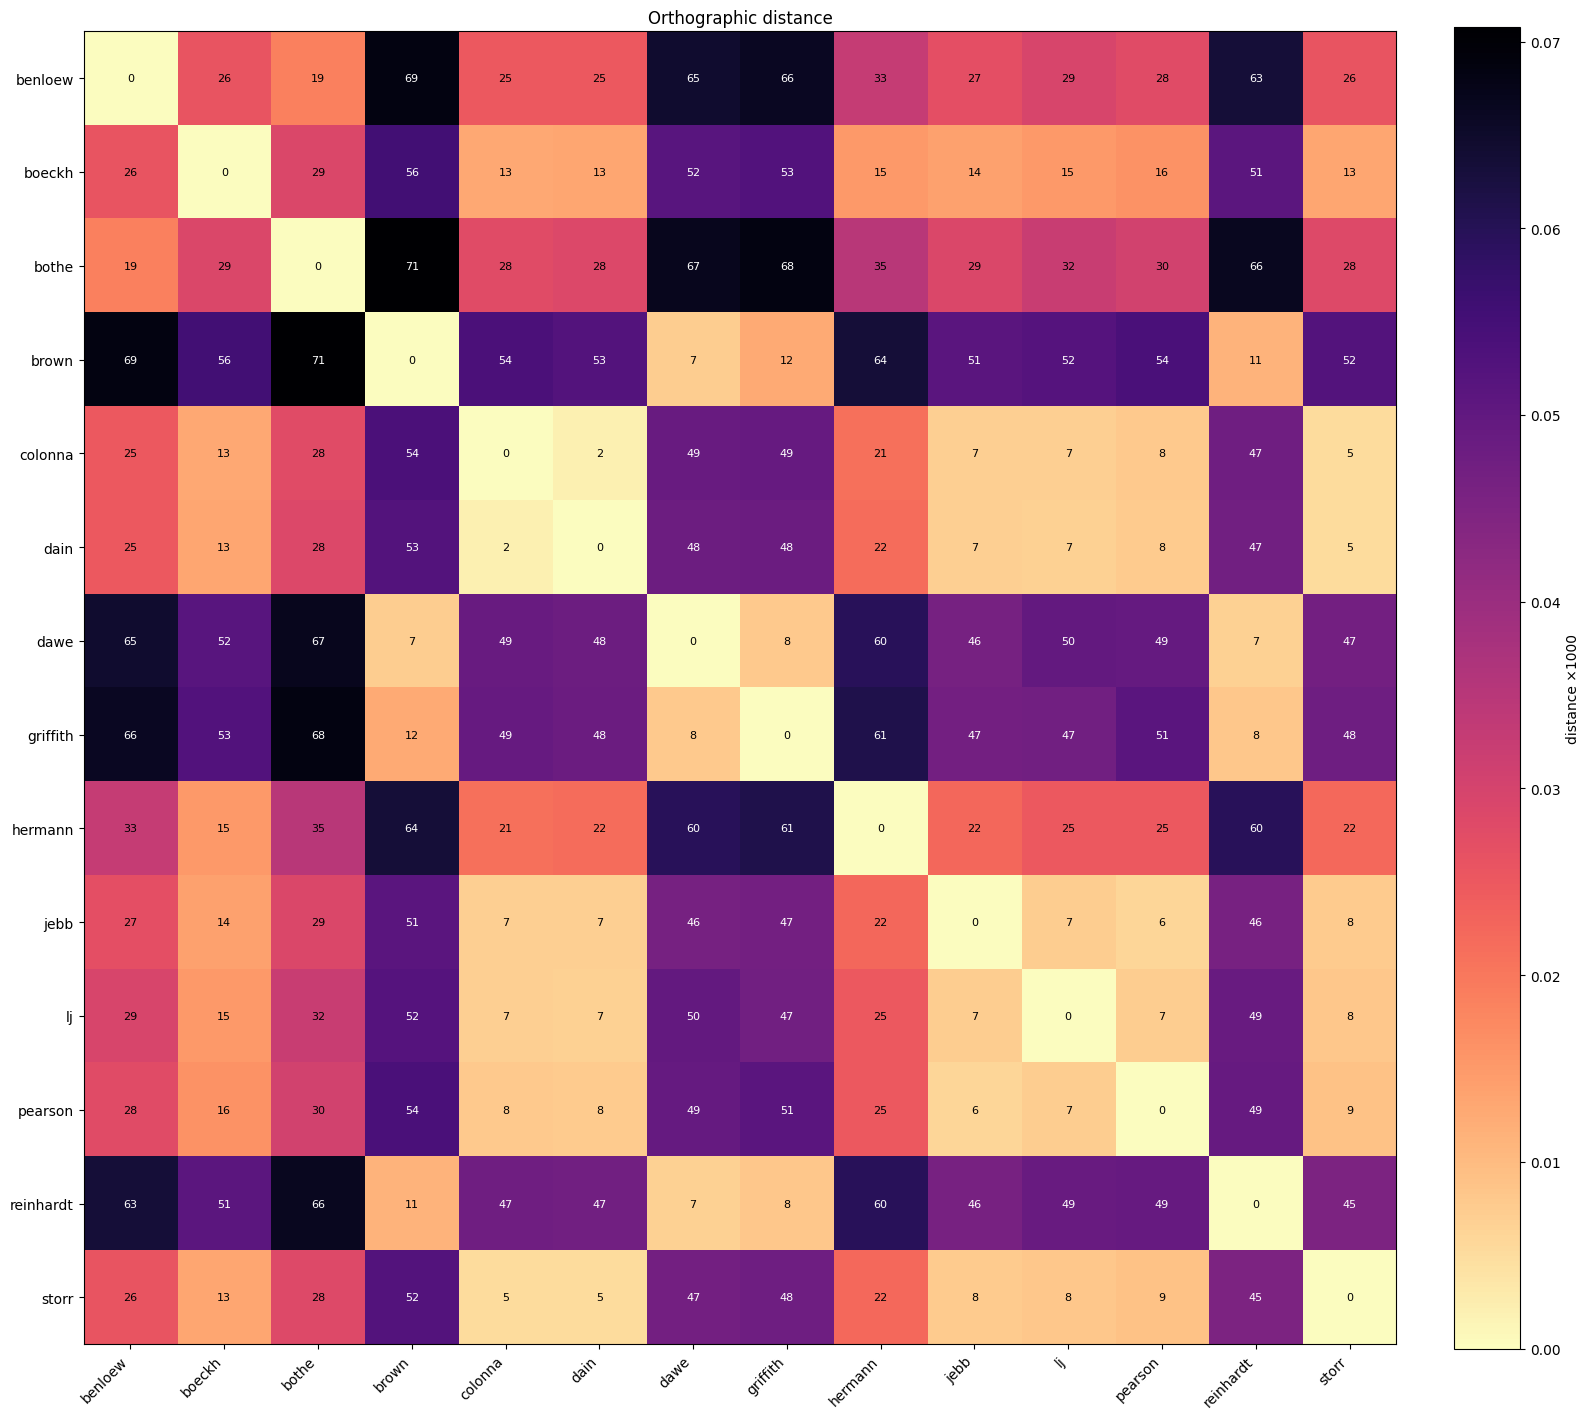

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

def heatmap(D, title):
    labels = list(D.index)
    fig, ax = plt.subplots(figsize=(1.0*len(labels)+2, 1.0*len(labels)+1))
    im = ax.imshow(D.values, cmap="magma_r")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    mx = D.values.max() or 1
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = D.values[i, j]
            ax.text(j, i, f"{v*1000:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if v > mx*0.5 else "black")
    ax.set_title(title)
    fig.colorbar(im, fraction=0.046, pad=0.04, label="distance ×1000")
    fig.tight_layout(); plt.show()

heatmap(Dword,  "Substantive (word-level) distance")
heatmap(Dortho, "Orthographic distance")

## 5 · Which text is closer to which?

UPGMA dendrograms cluster the editions; the neighbour-joining tree (written as Newick) gives
an unrooted relationship tree you can open in FigTree / iTOL. We build them for **both** signals
— readings and orthography — because they can tell different stories (e.g. two editions may share
a spelling convention while disagreeing on readings).

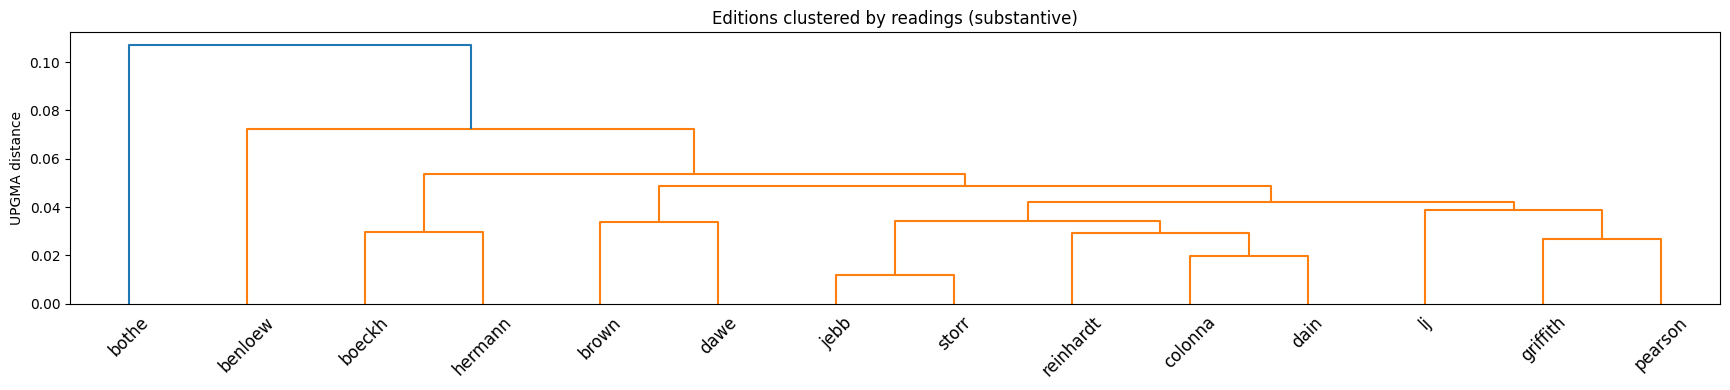

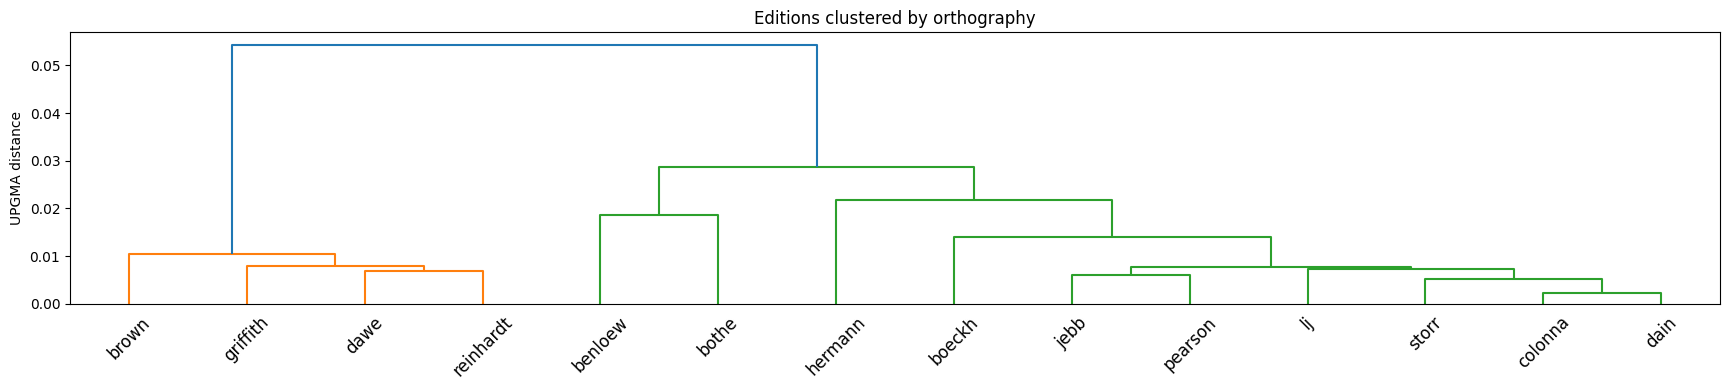

In [12]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

def upgma(D, title):
    condensed = squareform(D.values, checks=False)
    Z = linkage(condensed, method="average")
    fig, ax = plt.subplots(figsize=(1.1*len(D)+2, 4))
    dendrogram(Z, labels=list(D.index), ax=ax, leaf_rotation=45)
    ax.set_title(title); ax.set_ylabel("UPGMA distance")
    fig.tight_layout(); plt.show()
    return Z

_ = upgma(Dword,  "Editions clustered by readings (substantive)")
_ = upgma(Dortho, "Editions clustered by orthography")

In [13]:
def neighbor_joining(D):
    D = D.astype(float).copy()
    nodes = list(D.index)
    while D.shape[0] > 2:
        n = D.shape[0]
        r = D.values.sum(axis=1)
        Q = (n - 2) * D.values - r[:, None] - r[None, :]
        np.fill_diagonal(Q, np.inf)
        i, j = np.unravel_index(np.argmin(Q), Q.shape)
        di = 0.5 * D.values[i, j] + (r[i] - r[j]) / (2 * (n - 2))
        dj = D.values[i, j] - di
        new = f"({nodes[i]}:{max(di,0):.4f},{nodes[j]}:{max(dj,0):.4f})"
        nd = 0.5 * (D.values[i, :] + D.values[j, :] - D.values[i, j])
        keep = [k for k in range(n) if k not in (i, j)]
        lab = [nodes[k] for k in keep] + [new]
        M = D.values[np.ix_(keep, keep)]
        col = nd[keep]
        M = np.vstack([np.hstack([M, col[:, None]]), np.append(col, 0.0)])
        D = pd.DataFrame(M, index=lab, columns=lab)
        nodes = lab
    a, b = nodes
    return f"({a}:{D.values[0,1]/2:.4f},{b}:{D.values[0,1]/2:.4f});"

newick_word  = neighbor_joining(Dword)
newick_ortho = neighbor_joining(Dortho)
print("NJ / substantive:\n", newick_word)
print("\nNJ / orthographic:\n", newick_ortho)

NJ / substantive:
 (((brown:0.0127,dawe:0.0211):0.0086,(lj:0.0215,((((benloew:0.0313,bothe:0.0666):0.0082,(boeckh:0.0138,hermann:0.0160):0.0029):0.0116,(jebb:0.0054,storr:0.0067):0.0080):0.0029,(reinhardt:0.0136,(colonna:0.0086,dain:0.0113):0.0058):0.0024):0.0055):0.0041):0.0001,(griffith:0.0097,pearson:0.0172):0.0001);

NJ / orthographic:
 ((((reinhardt:0.0032,(griffith:0.0044,(brown:0.0059,dawe:0.0016):0.0020):0.0004):0.0387,((benloew:0.0079,bothe:0.0106):0.0108,(boeckh:0.0032,hermann:0.0117):0.0031):0.0029):0.0014,(lj:0.0037,(jebb:0.0024,pearson:0.0036):0.0006):0.0011):0.0002,(storr:0.0027,(colonna:0.0011,dain:0.0011):0.0013):0.0002);


## 6 · Inline pairwise diff viewer

Colour-coded, word-level, for any pair over any reference-line range. Yellow = different word
(replace), green = present only in the right edition, red strike-through = present only in the
left. A faint underline marks a word that matches but is spelled differently.

In [14]:
from IPython.display import HTML, display

_CSS = '''<style>
.coll{font-family:serif;font-size:1.05em;line-height:2.1;margin:.3em 0}
.coll .sig{display:inline-block;width:5.5em;color:#868e96;font-family:sans-serif;font-size:.8em}
.eq{} .ortho{border-bottom:1px dotted #adb5bd}
.rep{background:#fff3bf;border-radius:3px;padding:0 2px}
.ins{background:#d3f9d8;border-radius:3px;padding:0 2px}
.del{background:#ffe3e3;text-decoration:line-through;border-radius:3px;padding:0 2px}
</style>'''

def _slice(s, lines):
    df = EDS[s]
    return df[df['line_n'].isin([str(x) for x in lines])]

def diff_pair(sa, sb, lines):
    a = _slice(sa, lines); b = _slice(sb, lines)
    ak, bk = a['kw'].tolist(), b['kw'].tolist()
    af, bf = a['kf'].tolist(), b['kf'].tolist()
    ar, br = a['raw'].tolist(), b['raw'].tolist()
    top, bot = [], []
    for tag, i1, i2, j1, j2 in align(ak, bk):
        if tag == 'equal':
            for k in range(i2 - i1):
                cls = 'ortho' if af[i1+k] != bf[j1+k] else 'eq'
                top.append(f"<span class='{cls}'>{_html.escape(ar[i1+k])}</span>")
                bot.append(f"<span class='{cls}'>{_html.escape(br[j1+k])}</span>")
        elif tag == 'replace':
            top.append("<span class='rep'>" + _html.escape(' '.join(ar[i1:i2])) + "</span>")
            bot.append("<span class='rep'>" + _html.escape(' '.join(br[j1:j2])) + "</span>")
        elif tag == 'delete':
            top.append("<span class='del'>" + _html.escape(' '.join(ar[i1:i2])) + "</span>")
        else:
            bot.append("<span class='ins'>" + _html.escape(' '.join(br[j1:j2])) + "</span>")
    h = (_CSS + f"<div class='coll'><span class='sig'>{sa}</span>" + ' '.join(top) + '</div>'
         + f"<div class='coll'><span class='sig'>{sb}</span>" + ' '.join(bot) + '</div>')
    return HTML(h)

# examples: near-identical pair, and the divergent Dawe (with cruces/conjectures)
display(diff_pair('storr', 'jebb', range(1, 7)))
display(diff_pair('storr', 'dawe', [23, 24, 25]))
diff_pair('storr', 'reinhardt', [3, 4])

## 7 · Reference-anchored collation table & apparatus

`align_to_reference` lays every edition against the reference token grid (one row per reference
word). `build_apparatus` then keeps only the loci where editions disagree on the *word*, listing
each reading with the sigla that carry it — a machine-generated *apparatus criticus*.

In [15]:
def align_to_reference(ref):
    R = EDS[ref]
    rk = R['kw'].tolist()
    table = pd.DataFrame({'ref_line': R['line_n'].values,
                          'ref_widx': R['widx'].values,
                          ref: R['raw'].values})
    insertions = defaultdict(lambda: defaultdict(list))
    for s in SIGLA:
        if s == ref: continue
        E = EDS[s]; ek = E['kw'].tolist(); er = E['raw'].tolist()
        col = [''] * len(rk)
        for tag, i1, i2, j1, j2 in align(rk, ek):
            if tag == 'equal':
                for k in range(i2 - i1): col[i1 + k] = er[j1 + k]
            elif tag == 'replace':
                m = min(i2 - i1, j2 - j1)
                for k in range(m): col[i1 + k] = er[j1 + k]
                if (j2 - j1) > m: insertions[i1 + m - 1][s].extend(er[j1 + m:j2])
            elif tag == 'insert':
                insertions[i1 - 1][s].extend(er[j1:j2])
        table[s] = col
    return table, insertions

def build_apparatus(collation):
    rows = []
    for idx, r in collation.iterrows():
        readings = defaultdict(list)
        for s in SIGLA:
            tok = r[s]
            readings[key_word(tok) if tok else ''].append(s)
        nonempty = {k: v for k, v in readings.items() if k}
        if len(nonempty) <= 1: continue
        variants = []
        for k, sigs in sorted(nonempty.items(), key=lambda kv: -len(kv[1])):
            sample = collation.loc[idx, sigs[0]]
            variants.append(f"{sample} [{','.join(sorted(sigs))}]")
        gapped = [s for s in SIGLA if not r[s]]
        rows.append(dict(ref_line=r['ref_line'], ref_widx=int(r['ref_widx']),
                         lemma=r[REFERENCE], n_readings=len(nonempty),
                         apparatus='  |  '.join(variants),
                         omit=','.join(sorted(gapped))))
    return pd.DataFrame(rows)

collation, insertions = align_to_reference(REFERENCE)
apparatus = build_apparatus(collation)
print(f"{len(apparatus)} loci of word-level disagreement across {len(collation)} reference tokens")
apparatus.head(15)

852 loci of word-level disagreement across 7359 reference tokens


,ref_line,ref_widx,lemma,n_readings,apparatus,omit
0,2,6,οἶσθʼ,2,"οἶσθ᾽ [benloew,boeckh,brown,colonna,dain,dawe,...",
1,2,7,ὅ,2,"ὅ [brown,colonna,dain,dawe,griffith,jebb,pears...",bothe
2,3,14,ὁποῖον,2,"ὁποῖον [benloew,boeckh,bothe,brown,colonna,dai...",
3,4,24,οὔτʼ,2,"οὔτ᾽ [benloew,boeckh,brown,colonna,dain,dawe,g...",
4,4,25,ἄτης,2,"ἄτης [benloew,boeckh,bothe,brown,colonna,dain,...",
5,4,26,ἄτερ,2,"ἄτερ [benloew,boeckh,bothe,brown,colonna,dain,...",griffith
6,6,37,κἀμῶν,2,"κἀμῶν [benloew,boeckh,brown,colonna,dain,dawe,...",
7,6,38,οὐκ,2,"οὐκ [benloew,boeckh,bothe,brown,dain,dawe,grif...",
8,12,79,ἐξ,2,"ἐξ [benloew,bothe,brown,colonna,dain,dawe,grif...",
9,14,86,θανόντοιν,2,"θανόντων [benloew,boeckh,bothe,colonna,dain,he...",


### Most-contested lines, and a readable apparatus for one of them

In [16]:
hot = (apparatus.groupby('ref_line').size().sort_values(ascending=False)
        .rename('n_variants').reset_index())
display(hot.head(15))

def show_locus(line_n):
    sub = apparatus[apparatus['ref_line'] == str(line_n)]
    for _, r in sub.iterrows():
        print(f"  {r['ref_line']:>5}.{r['ref_widx']:<6} {r['lemma']:<14} -> {r['apparatus']}")
        if r['omit']: print(f"          omit: {r['omit']}")

print('Apparatus for the most-contested line:')
show_locus(int(hot.iloc[0]['ref_line']))
print()
print('Apparatus for line 24 (the χρήσει / χρησθεὶς crux):')
show_locus(24)

,ref_line,n_variants
0,1289,7
1,567,6
2,850,5
3,865,5
4,810,5
5,1301,5
6,351,5
7,845,5
8,1342,5
9,139,4


Apparatus for the most-contested line:
   1289.7067   φής,           -> φὴς, [benloew,boeckh,griffith,jebb,lj,pearson,reinhardt,storr]  |  φῇς, [bothe,brown,colonna,dain,dawe,hermann]
   1289.7068   παῖ;           -> παῖ, [boeckh,bothe,brown,colonna,dain,dawe,griffith,jebb,lj,pearson,reinhardt,storr]  |  τίνα [benloew,hermann]
   1289.7069   τίνʼ           -> τίν᾽ [bothe,brown,dain,dawe,griffith,reinhardt,storr]  |  τίνα [boeckh,colonna,jebb,pearson]  |  τί [lj]
          omit: benloew,hermann
   1289.7070   αὖ             -> αὖ [brown,dain,dawe,griffith,lj,reinhardt,storr]  |  αὐδᾷς [bothe]
          omit: benloew,boeckh,colonna,hermann,jebb,pearson
   1289.7071   λέγεις         -> λέγεις [benloew,boeckh,brown,colonna,dain,dawe,griffith,hermann,jebb,lj,pearson,reinhardt,storr]  |  λόγον; [bothe]
   1289.7072   μοι            -> μοι [benloew,boeckh,brown,colonna,dain,dawe,griffith,hermann,jebb,lj,pearson,reinhardt,storr]  |  αἶ, [bothe]
   1289.7073   νέον,          -> νέον, [boeckh,br

## 8 · Export crosswalks (no source XML touched)

In [17]:
paths = {}
os.makedirs(OUTPUT_DIR, exist_ok=True)
paths['collation'] = os.path.join(OUTPUT_DIR, f'antigone_collation_ref-{REFERENCE}.tsv')
paths['apparatus'] = os.path.join(OUTPUT_DIR, 'antigone_apparatus.tsv')
paths['d_word']    = os.path.join(OUTPUT_DIR, 'antigone_distance_substantive.tsv')
paths['d_ortho']   = os.path.join(OUTPUT_DIR, 'antigone_distance_orthographic.tsv')
paths['nj_word']   = os.path.join(OUTPUT_DIR, 'antigone_nj_substantive.nwk')
paths['nj_ortho']  = os.path.join(OUTPUT_DIR, 'antigone_nj_orthographic.nwk')

collation.to_csv(paths['collation'], sep='\t', index=False)
apparatus.to_csv(paths['apparatus'], sep='\t', index=False)
Dword.to_csv(paths['d_word'], sep='\t')
Dortho.to_csv(paths['d_ortho'], sep='\t')
open(paths['nj_word'], 'w').write(newick_word + '\n')
open(paths['nj_ortho'], 'w').write(newick_ortho + '\n')
for k, v in paths.items():
    print(f'{k:10} -> {v}')

collation  -> /Users/gcrane/github/AntigonesPublic/greek/outputs/antigone_collation_ref-storr.tsv
apparatus  -> /Users/gcrane/github/AntigonesPublic/greek/outputs/antigone_apparatus.tsv
d_word     -> /Users/gcrane/github/AntigonesPublic/greek/outputs/antigone_distance_substantive.tsv
d_ortho    -> /Users/gcrane/github/AntigonesPublic/greek/outputs/antigone_distance_orthographic.tsv
nj_word    -> /Users/gcrane/github/AntigonesPublic/greek/outputs/antigone_nj_substantive.nwk
nj_ortho   -> /Users/gcrane/github/AntigonesPublic/greek/outputs/antigone_nj_orthographic.nwk


## 9 · Notes & next steps

- **Add the other editions** by dropping their `.xml` files into an `INPUT_DIRS` folder
  folder — `discover()` picks them up and every matrix/tree/table scales automatically.
- **Two signals, two stories.** Cluster on `Dword` for textual affiliation (shared readings),
  on `Dortho` for editorial/orthographic convention (iota adscript vs subscript, accentuation).
- **Plugging into `persverscomp`.** The exported `*.tsv` files are crosswalks of exactly the kind
  the parallel reader consumes: `antigone_collation_ref-<siglum>.tsv` is a ready word-grid, and
  `antigone_apparatus.tsv` is a per-locus variant index. Nothing here rewrites the TEI.
- **Reference bias.** Re-run with a different `REFERENCE` (or anchor on the edition with the most
  tokens) to surface readings the current baseline omits. For a reference-free wide alignment,
  this pairs naturally with your anchor-based `align_editions.ipynb`: use its anchors to seed
  columns, then fill gaps with the pairwise opcodes computed here.
- **Trees.** The `.nwk` files open in FigTree / iTOL / Dendroscope; neighbour-joining gives an
  unrooted relationship graph, while the in-notebook dendrograms are UPGMA (ultrametric).